In [4]:
from collections import defaultdict
import os
import random
import numpy as np
import pandas as pd
import json
import pickle
import gzip
from tqdm import tqdm

def load_pickle(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)


def save_pickle(data, filename):
    with open(filename, "wb") as f:
        pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_json(file_path):
    with open(file_path, "r") as f:
        return json.load(f)
    
def ReadLineFromFile(path):
    lines = []
    with open(path,'r') as fd:
        for line in fd:
            lines.append(line.rstrip('\n'))
    return lines

def parse(path):
    g = gzip.open(path, 'r')
    for l in g:
        # l = l.replace('false', 'False').replace('true', 'True')
        # Convert bytes to string
        data_str = l.decode('utf-8')
        # Replace 'false' with 'False' and 'true' with 'True'
        data_str = data_str.replace('false', 'False').replace('true', 'True')

        # Parse the JSON string into a dictionary
        yield eval(data_str)
'''
Set seeds
'''
seed = 999
random.seed(seed)
np.random.seed(seed)

In [5]:
short_data_name = 'clothing'

In [6]:
import numpy as np
import matplotlib.pyplot as plt
def print_distribution_stats(distribution, title):
    dist = np.array(distribution)

    print(f"\n📊 {title}")
    print(f"Total Samples: {len(dist)}")
    print(f"Min   : {np.min(dist)}")
    print(f"Max   : {np.max(dist)}")
    print(f"Mean         : {np.mean(dist):.2f}")
    print(f"Median       : {np.median(dist)}")
    print(f"Std Dev      : {np.std(dist):.2f}")
    print(f"25th %ile    : {np.percentile(dist, 25)}")
    print(f"50th %ile    : {np.percentile(dist, 50)}")
    print(f"75th %ile    : {np.percentile(dist, 75)}")
    print(f"90th %ile    : {np.percentile(dist, 90)}")
    print(f"95th %ile    : {np.percentile(dist, 95)}")
    print(f"99th %ile    : {np.percentile(dist, 99)}")



# Create Splits for Review

In [7]:
datamaps = load_json("../data/{}/datamaps.json".format(short_data_name))
print(datamaps.keys())

dict_keys(['user2id', 'item2id', 'id2user', 'id2item', 'attribute2id', 'id2attribute', 'attributeid2num'])


In [8]:
exp_data = load_pickle("../data/{}/exp_splits.pkl".format(short_data_name))
exp_data.keys()

dict_keys(['train', 'val', 'test'])

In [9]:
rev_data = load_pickle("../data/{}/review_splits.pkl".format(short_data_name))
rev_data.keys()

dict_keys(['train', 'val', 'test', 'train_indices', 'val_indices', 'test_indices'])

In [10]:
meta_data = []
for meta in parse(os.path.join("../data", short_data_name, 'meta.json.gz')):
    meta_data.append(meta)
meta_dict = {}
for i, meta_item in enumerate(meta_data):
    meta_dict[meta_item['asin']] = i

In [11]:
rev_data['train'][0]

{'reviewerID': 'A1KLRMWW2FWPL4',
 'asin': '0000031887',
 'reviewerName': 'Amazon Customer "cameramom"',
 'helpful': [0, 0],
 'reviewText': "This is a great tutu and at a really great price. It doesn't look cheap at all. I'm so glad I looked on Amazon and found such an affordable tutu that isn't made poorly. A++",
 'overall': 5.0,
 'summary': 'Great tutu-  not cheaply made',
 'unixReviewTime': 1297468800,
 'reviewTime': '02 12, 2011',
 'explanation': 'This is a great tutu and at a really great price',
 'feature': 'price'}

In [12]:
len(rev_data['train_indices']) + len(rev_data['val_indices']) + len(rev_data['test_indices'])

278677

In [13]:
len(exp_data['train']) + len(exp_data['test']) + len(exp_data['val'])

178936

In [14]:
seq_data = ReadLineFromFile(f"../data/{short_data_name}/sequential_data.txt")
len(seq_data)

39387

In [15]:
sum([len(x.split()) - 1 for x in seq_data])

278677

In [16]:
users, items = len(datamaps['user2id']), len(datamaps['item2id'])
count = len(rev_data['train']) + len(rev_data['test']) + len(rev_data['val'])
print("# Users: ",users)
print("# Items: ",items)
print("# Reviews: ",count)
print("Sparsity: ",count * 100.0 / (users * items),'%')

# Users:  39387
# Items:  23033
# Reviews:  278677
Sparsity:  0.03071833809100676 %


In [17]:
counts = {float(r): 0 for r in range(1,6)}
for record in rev_data['train']:
    counts[record['overall']] += 1
T = sum(counts.values())
print(T)
for k,c in counts.items():
    counts[k] = float(counts[k])/T
print(counts)

222942
{1.0: 0.04023019440033731, 2.0: 0.05553462335495331, 3.0: 0.1091539503548008, 4.0: 0.20900503269908766, 5.0: 0.5860761991908209}


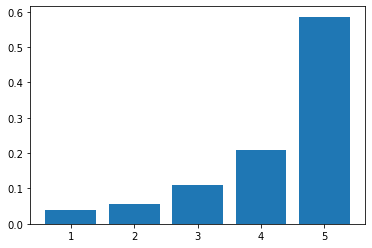

In [18]:
import matplotlib.pyplot as plt
X = [float(r) for r in range(1,6)]
plt.bar(X, [counts[x] for x in X])
plt.show()

In [19]:
rating_info = {}
for datum in tqdm(rev_data['train'] + rev_data['val']):
    user_desc = datum['reviewerID']
    item_name = datum['asin']
    user_id = datamaps['user2id'][user_desc]
    item_id = datamaps['item2id'][item_name]
    rating = datum['overall']
    if user_id not in rating_info:
        rating_info[user_id] = {"liked":[],"disliked":[]}
    if rating <= 4:
        rating_info[user_id]['disliked'].append(item_id)
    else:
        rating_info[user_id]['liked'].append(item_id)

100%|██████████| 250810/250810 [00:00<00:00, 883009.52it/s]


In [20]:
list(rating_info.items())[0]

('39184',
 {'liked': ['9864', '1330', '14056', '18735', '19632'],
  'disliked': ['7069', '6105']})

In [21]:
likes = [len(dic['liked']) for user,dic in rating_info.items()]
dislikes = [len(dic['disliked']) for user,dic in rating_info.items()]
total = [len(line.split(' ')) - 1 - 1 for line in seq_data] # extra -1 for the test item


📊 Total Seq Len Items Count
Total Samples: 39387
Min   : 4
Max   : 135
Mean         : 6.08
Median       : 5.0
Std Dev      : 3.59
25th %ile    : 4.0
50th %ile    : 5.0
75th %ile    : 7.0
90th %ile    : 9.0
95th %ile    : 12.0
99th %ile    : 20.0


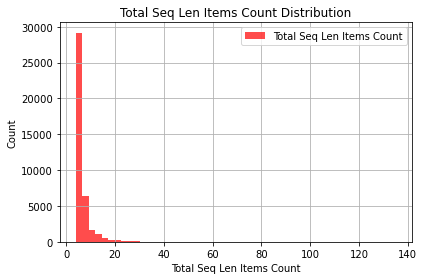

In [22]:
print_distribution_stats(total,'Total Seq Len Items Count')
plt.hist(total, bins=50, alpha=0.7, label='Total Seq Len Items Count', color='red')
plt.xlabel('Total Seq Len Items Count')
plt.ylabel("Count")
plt.title("Total Seq Len Items Count Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


📊 Liked Items Count
Total Samples: 39387
Min   : 0
Max   : 119
Mean         : 3.73
Median       : 3.0
Std Dev      : 2.73
25th %ile    : 2.0
50th %ile    : 3.0
75th %ile    : 5.0
90th %ile    : 6.0
95th %ile    : 8.0
99th %ile    : 13.0


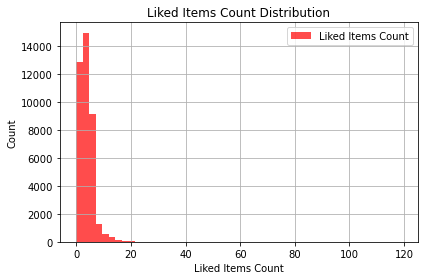

In [23]:
print_distribution_stats(likes,'Liked Items Count')
plt.hist(likes, bins=50, alpha=0.7, label='Liked Items Count', color='red')
plt.xlabel('Liked Items Count')
plt.ylabel("Count")
plt.title("Liked Items Count Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


📊 DisLiked Items Count
Total Samples: 39387
Min   : 0
Max   : 53
Mean         : 2.64
Median       : 2.0
Std Dev      : 2.29
25th %ile    : 1.0
50th %ile    : 2.0
75th %ile    : 4.0
90th %ile    : 5.0
95th %ile    : 6.0
99th %ile    : 10.0


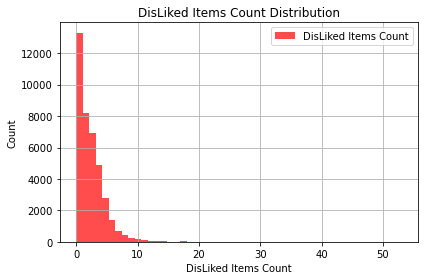

In [24]:
print_distribution_stats(dislikes,'DisLiked Items Count')
plt.hist(dislikes, bins=50, alpha=0.7, label='DisLiked Items Count', color='red')
plt.xlabel('DisLiked Items Count')
plt.ylabel("Count")
plt.title("DisLiked Items Count Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()